# 07. Priorización mensual de la exposición marítima para la planificación portuaria en 2027

## TFM: clima marítimo cantábrico y gestión portuaria

Usa los resultados estadísticos del Notebook 06 para transformar la predicción mensual de Hs de 2027 en un apoyo sencillo a la planificación estacional.

La prioridad se calcula dentro de cada boya: el puesto 1 corresponde al mes con mayor Hs media prevista. La dirección es una climatología histórica mensual, no una predicción para 2027.


Se utiliza el archivo generado en el notebook 06 `08_apoyo_planificacion_portuaria_2027.csv`.

In [1]:
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
NOMBRE_ARCHIVO = "08_apoyo_planificacion_portuaria_2027.csv"

def localizar_archivo(nombre):
    candidatos = [
        Path("/content/resultados_notebook_06/tablas") / nombre,
        Path("/content/tablas") / nombre,
        Path("/content") / nombre,
    ]
    encontrados = [p for p in candidatos if p.exists()]
    if not encontrados:
        encontrados = list(Path("/content").rglob(nombre))
    return encontrados[0] if encontrados else None

ruta_entrada = localizar_archivo(NOMBRE_ARCHIVO)
if ruta_entrada is None:
    print(f"No se ha encontrado {NOMBRE_ARCHIVO}. Súbelo desde tu ordenador.")
    from google.colab import files
    subida = files.upload()
    if NOMBRE_ARCHIVO not in subida:
        raise FileNotFoundError(f"Debes subir exactamente {NOMBRE_ARCHIVO}, generado por el Notebook 06.")
    ruta_entrada = Path("/content") / NOMBRE_ARCHIVO

print(f"Archivo utilizado: {ruta_entrada}")

Archivo utilizado: /content/08_apoyo_planificacion_portuaria_2027.csv


In [3]:
df = pd.read_csv(ruta_entrada, encoding="utf-8-sig")
df["fecha"] = pd.to_datetime(df["fecha"])

columnas_necesarias = {
    "codigo_boya", "nombre_boya", "fecha", "nombre_mes", "Hs_predicha_m",
    "banda_inferior_p10_m", "banda_superior_p90_m", "MAE_validacion_m",
    "ranking_Hs_2027", "Hs_p95_historico_m", "porcentaje_horas_Hs_ge_3",
    "sector_predominante_historico", "frecuencia_sector_predominante_pct", "modelo"
}
faltan = columnas_necesarias - set(df.columns)
if faltan:
    raise ValueError(f"Faltan columnas: {sorted(faltan)}")
if len(df) != 48 or df["codigo_boya"].nunique() != 4:
    print("Aviso: se esperaban 48 filas y cuatro boyas. Revisa la salida del Notebook 06.")

df = df.sort_values(["nombre_boya", "fecha"]).copy()
df["mes_num"] = df["fecha"].dt.month
df["prioridad"] = df["ranking_Hs_2027"].astype(int)
print("Registros disponibles:", len(df))
display(df.head())

Registros disponibles: 48


,codigo_boya,nombre_boya,fecha,nombre_mes,estacion,Hs_predicha_m,banda_inferior_p10_m,banda_superior_p90_m,MAE_validacion_m,ranking_Hs_2027,Hs_p95_historico_m,porcentaje_horas_Hs_ge_3,sector_predominante_historico,frecuencia_sector_predominante_pct,modelo,mes_num,prioridad
0,1103,Bilbao costera,2027-01-01,Enero,Invierno,1.94,1.67,2.32,0.17,3,4.04,15.77,NO,79.34,Holt-Winters aditivo amortiguado,1,3
1,1103,Bilbao costera,2027-02-01,Febrero,Invierno,1.77,1.50,2.15,0.17,4,3.59,10.84,NO,69.68,Holt-Winters aditivo amortiguado,2,4
2,1103,Bilbao costera,2027-03-01,Marzo,Primavera,1.60,1.33,1.97,0.17,5,3.29,7.49,NO,73.29,Holt-Winters aditivo amortiguado,3,5
3,1103,Bilbao costera,2027-04-01,Abril,Primavera,1.27,1.00,1.65,0.17,7,2.52,2.25,NO,71.07,Holt-Winters aditivo amortiguado,4,7
4,1103,Bilbao costera,2027-05-01,Mayo,Primavera,1.16,0.89,1.54,0.17,9,2.29,1.38,NO,75.40,Holt-Winters aditivo amortiguado,5,9


## Criterio de priorización

El criterio principal es la Hs media mensual prevista por Holt-Winters en el Notebook 06. Se asigna el puesto 1 al mes con mayor Hs prevista en cada boya. El percentil 95 histórico, el porcentaje de horas con Hs ≥ 3 m y el sector más frecuente sirven para aportar contexto, pero no cambian el ranking.

In [4]:
columnas_salida = [
    "nombre_boya", "fecha", "nombre_mes", "estacion", "prioridad", "Hs_predicha_m",
    "banda_inferior_p10_m", "banda_superior_p90_m", "Hs_p95_historico_m",
    "porcentaje_horas_Hs_ge_3", "sector_predominante_historico",
    "frecuencia_sector_predominante_pct", "MAE_validacion_m", "modelo"
]
tabla_priorizacion = df[columnas_salida].sort_values(["nombre_boya", "prioridad"]).copy()
tabla_priorizacion = tabla_priorizacion.rename(columns={
    "nombre_boya":"Boya", "fecha":"Fecha", "nombre_mes":"Mes", "estacion":"Estacion",
    "prioridad":"Prioridad_Hs_2027", "Hs_predicha_m":"Hs_media_prevista_m",
    "banda_inferior_p10_m":"P10_m", "banda_superior_p90_m":"P90_m",
    "Hs_p95_historico_m":"Hs_P95_historico_m",
    "porcentaje_horas_Hs_ge_3":"Horas_historicas_Hs_ge_3_pct",
    "sector_predominante_historico":"Sector_historico_predominante",
    "frecuencia_sector_predominante_pct":"Frecuencia_sector_pct",
    "modelo":"Metodo"
})

tabla_meses_prioritarios = tabla_priorizacion.query("Prioridad_Hs_2027 <= 3").sort_values(["Boya", "Prioridad_Hs_2027"]).copy()
tabla_meses_prioritarios["Interpretacion"] = tabla_meses_prioritarios.apply(
    lambda r: f"Prioridad {int(r['Prioridad_Hs_2027'])}: {r['Mes']}; Hs prevista {r['Hs_media_prevista_m']:.2f} m; sector histórico dominante {r['Sector_historico_predominante']} ({r['Frecuencia_sector_pct']:.0f} %).", axis=1)

resumen = (tabla_meses_prioritarios.pivot(index="Boya", columns="Prioridad_Hs_2027", values=["Mes", "Hs_media_prevista_m"])
           .sort_index(axis=1, level=1))
resumen.columns = [f"{a}_{int(b)}" for a, b in resumen.columns]
tabla_resumen_boyas = resumen.reset_index()

display(tabla_meses_prioritarios)

,Boya,Fecha,Mes,Estacion,Prioridad_Hs_2027,Hs_media_prevista_m,P10_m,P90_m,Hs_P95_historico_m,Horas_historicas_Hs_ge_3_pct,Sector_historico_predominante,Frecuencia_sector_pct,MAE_validacion_m,Metodo,Interpretacion
10,Bilbao costera,2027-11-01,Noviembre,Otoño,1,1.99,1.72,2.37,3.90,15.15,NO,83.73,0.17,Holt-Winters aditivo amortiguado,Prioridad 1: Noviembre; Hs prevista 1.99 m; se...
11,Bilbao costera,2027-12-01,Diciembre,Invierno,2,1.98,1.70,2.35,4.05,14.98,NO,76.96,0.17,Holt-Winters aditivo amortiguado,Prioridad 2: Diciembre; Hs prevista 1.98 m; se...
0,Bilbao costera,2027-01-01,Enero,Invierno,3,1.94,1.67,2.32,4.04,15.77,NO,79.34,0.17,Holt-Winters aditivo amortiguado,Prioridad 3: Enero; Hs prevista 1.94 m; sector...
25,Bilbao-Vizcaya,2027-02-01,Febrero,Invierno,1,2.84,2.08,3.12,5.75,36.66,NO,69.80,0.29,Holt-Winters aditivo amortiguado,Prioridad 1: Febrero; Hs prevista 2.84 m; sect...
24,Bilbao-Vizcaya,2027-01-01,Enero,Invierno,2,2.79,2.04,3.08,5.80,35.16,NO,72.12,0.29,Holt-Winters aditivo amortiguado,Prioridad 2: Enero; Hs prevista 2.79 m; sector...
35,Bilbao-Vizcaya,2027-12-01,Diciembre,Invierno,3,2.61,1.86,2.90,5.42,32.13,NO,65.61,0.29,Holt-Winters aditivo amortiguado,Prioridad 3: Diciembre; Hs prevista 2.61 m; se...
37,Cabo de Peñas,2027-02-01,Febrero,Invierno,1,2.99,2.40,3.17,5.98,40.37,NO,72.67,0.28,Holt-Winters aditivo amortiguado,Prioridad 1: Febrero; Hs prevista 2.99 m; sect...
36,Cabo de Peñas,2027-01-01,Enero,Invierno,2,2.88,2.29,3.05,5.70,35.58,NO,72.48,0.28,Holt-Winters aditivo amortiguado,Prioridad 2: Enero; Hs prevista 2.88 m; sector...
47,Cabo de Peñas,2027-12-01,Diciembre,Invierno,3,2.74,2.15,2.91,5.42,35.77,NO,69.23,0.28,Holt-Winters aditivo amortiguado,Prioridad 3: Diciembre; Hs prevista 2.74 m; se...
22,Gijón costera,2027-11-01,Noviembre,Otoño,1,2.15,1.77,2.37,4.04,17.95,NO,62.56,0.19,Holt-Winters aditivo amortiguado,Prioridad 1: Noviembre; Hs prevista 2.15 m; se...


## Figura 1. Calendario de priorización mensual

Cada celda recoge la prioridad relativa, la Hs media prevista y el sector históricamente más frecuente. El color resume el orden de los meses **dentro de cada boya**, por lo que no es una comparación directa entre las boyas exteriores y costeras.

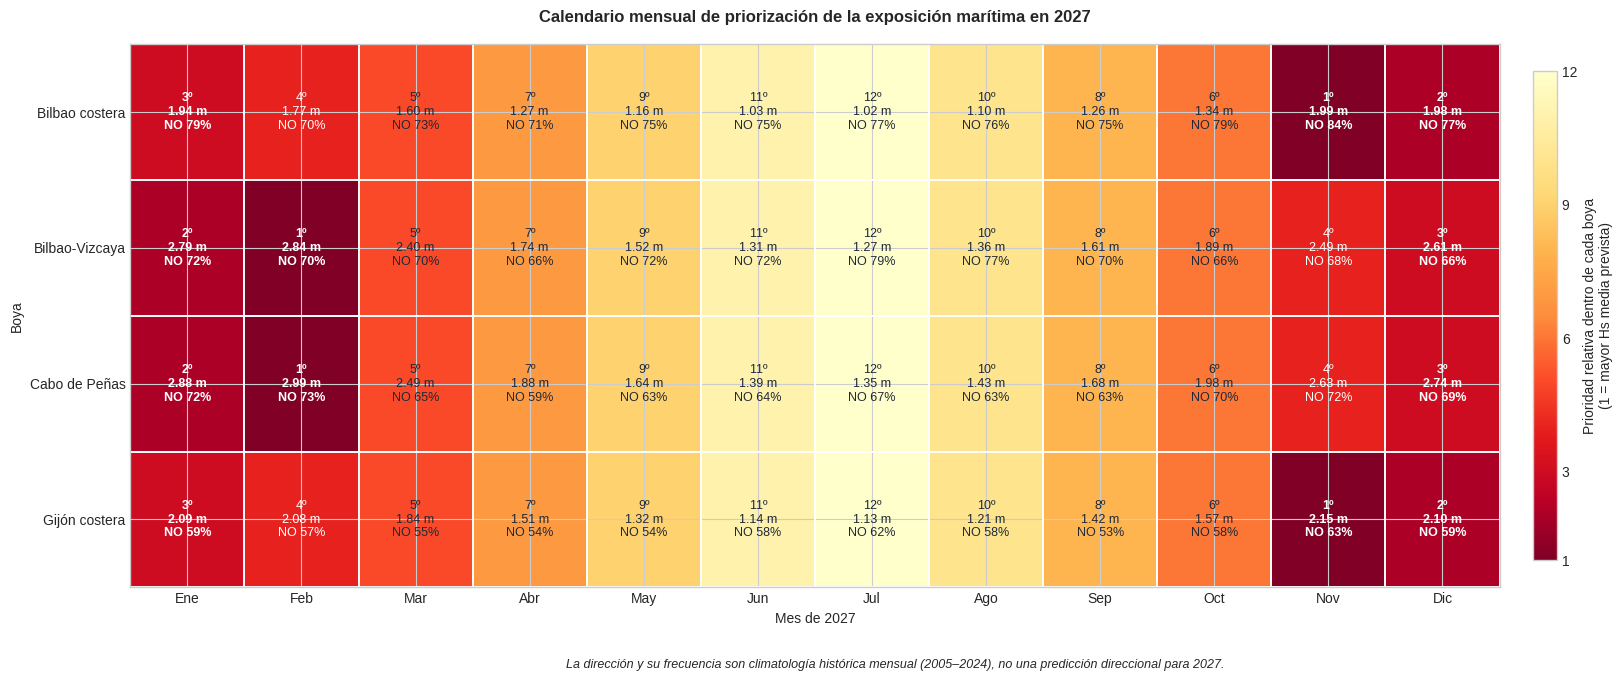

In [5]:
orden_boyas = df["nombre_boya"].drop_duplicates().tolist()
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
calendario = df.pivot(index="nombre_boya", columns="mes_num", values="prioridad").reindex(index=orden_boyas, columns=range(1, 13))

def crear_figura_calendario():
    fig, ax = plt.subplots(figsize=(18, 6.8))
    imagen = ax.imshow(calendario.values, cmap="YlOrRd_r", vmin=1, vmax=12, aspect="auto")
    ax.set_xticks(range(12), meses); ax.set_yticks(range(len(orden_boyas)), orden_boyas)
    ax.set_xlabel("Mes de 2027"); ax.set_ylabel("Boya")
    ax.set_title("Calendario mensual de priorización de la exposición marítima en 2027", pad=16, weight="bold")
    for i, boya in enumerate(orden_boyas):
        for j, mes in enumerate(range(1, 13)):
            fila = df[(df["nombre_boya"] == boya) & (df["mes_num"] == mes)].iloc[0]
            texto = f"{int(fila['prioridad'])}º\n{fila['Hs_predicha_m']:.2f} m\n{fila['sector_predominante_historico']} {fila['frecuencia_sector_predominante_pct']:.0f}%"
            ax.text(j, i, texto, ha="center", va="center", fontsize=9,
                    color="white" if fila["prioridad"] <= 4 else "#1f2937",
                    weight="bold" if fila["prioridad"] <= 3 else "normal")
    for x in np.arange(-0.5, 12, 1): ax.axvline(x, color="white", linewidth=1.4)
    for y in np.arange(-0.5, len(orden_boyas), 1): ax.axhline(y, color="white", linewidth=1.4)
    cbar = fig.colorbar(imagen, ax=ax, shrink=0.9, pad=0.02)
    cbar.set_label("Prioridad relativa dentro de cada boya\n(1 = mayor Hs media prevista)")
    cbar.set_ticks([1, 3, 6, 9, 12])
    fig.text(0.5, 0.01, "La dirección y su frecuencia son climatología histórica mensual (2005–2024), no una predicción direccional para 2027.", ha="center", fontsize=9, style="italic")
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    return fig

fig = crear_figura_calendario()
plt.show()

## Figura 2. Tres meses prioritarios y contexto histórico

Los rombos negros son el percentil 95 histórico de cada mes. Permiten contextualizar valores altos observados, pero no son una segunda predicción ni un límite operativo.

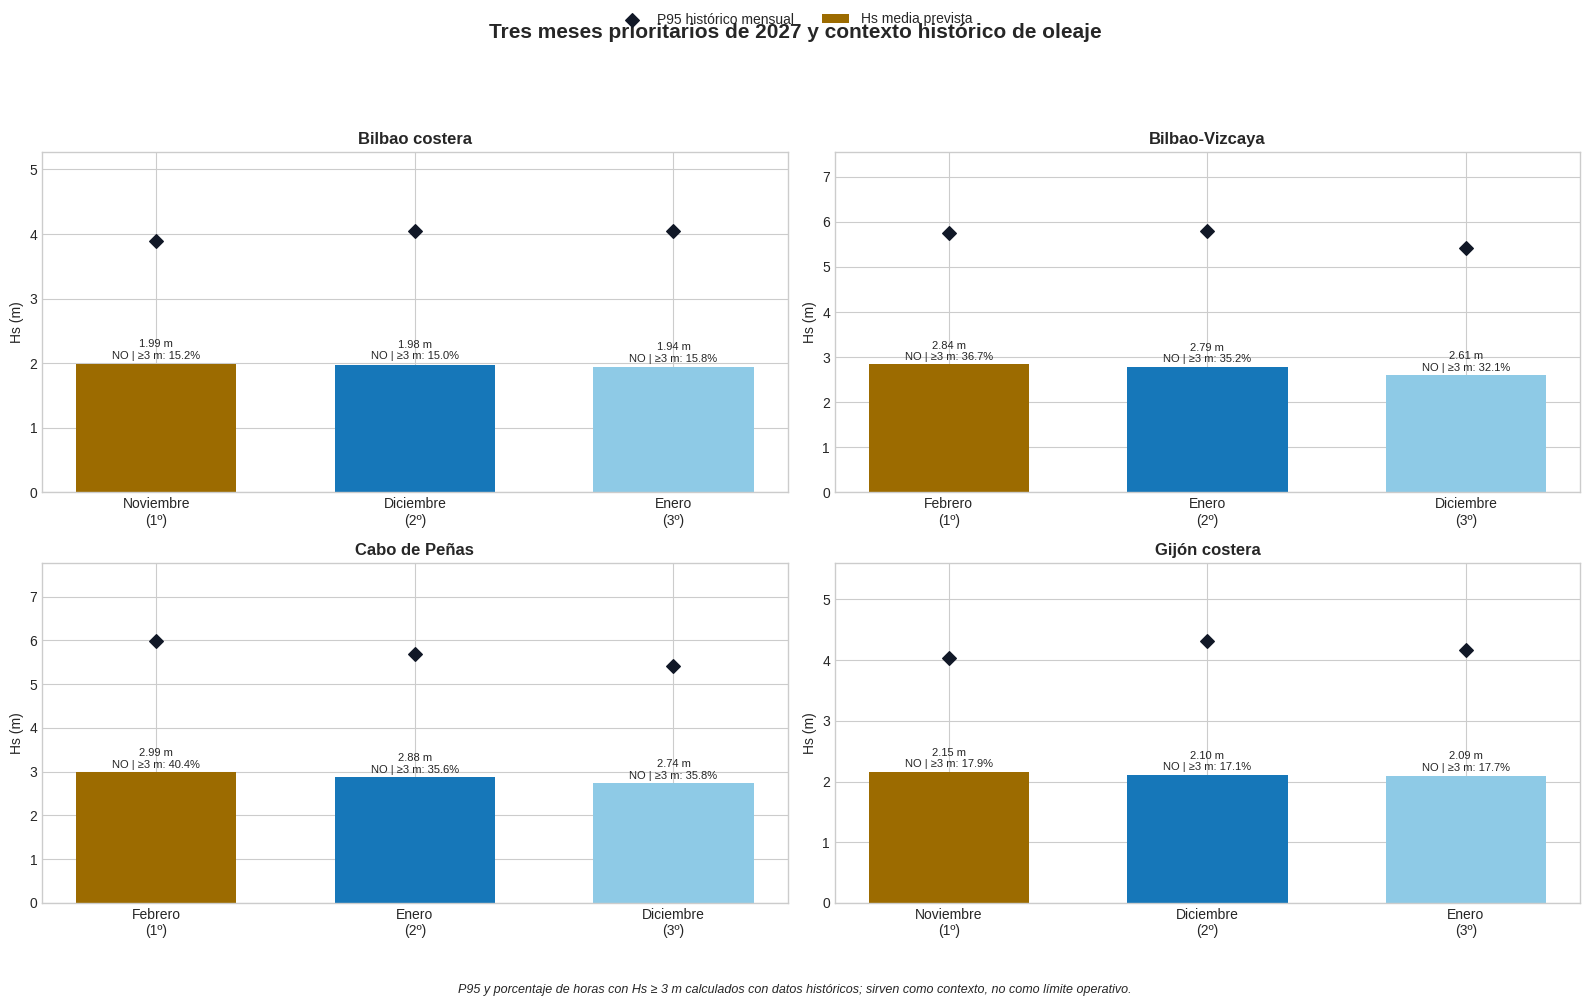

In [6]:
colores = ["#9c6b00", "#1677b9", "#8ecae6"]
def crear_figura_top3():
    fig, axes = plt.subplots(2, 2, figsize=(16, 10)); axes = axes.ravel()
    for ax, boya in zip(axes, orden_boyas):
        datos = tabla_meses_prioritarios[tabla_meses_prioritarios["Boya"] == boya].sort_values("Prioridad_Hs_2027")
        x = np.arange(len(datos))
        barras = ax.bar(x, datos["Hs_media_prevista_m"], color=colores, width=0.62, label="Hs media prevista")
        ax.scatter(x, datos["Hs_P95_historico_m"], marker="D", s=48, color="#111827", label="P95 histórico mensual", zorder=3)
        ax.set_xticks(x, [f"{m}\n({int(p)}º)" for m, p in zip(datos["Mes"], datos["Prioridad_Hs_2027"])])
        ax.set_title(boya, weight="bold"); ax.set_ylabel("Hs (m)")
        ax.set_ylim(0, max(datos["Hs_P95_historico_m"].max(), datos["Hs_media_prevista_m"].max()) * 1.30)
        for barra, (_, fila) in zip(barras, datos.iterrows()):
            ax.text(barra.get_x()+barra.get_width()/2, barra.get_height()+0.05,
                    f"{fila['Hs_media_prevista_m']:.2f} m\n{fila['Sector_historico_predominante']} | ≥3 m: {fila['Horas_historicas_Hs_ge_3_pct']:.1f}%",
                    ha="center", va="bottom", fontsize=8)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
    fig.suptitle("Tres meses prioritarios de 2027 y contexto histórico de oleaje", y=0.98, fontsize=15, weight="bold")
    fig.text(0.5, 0.01, "P95 y porcentaje de horas con Hs ≥ 3 m calculados con datos históricos; sirven como contexto, no como límite operativo.", ha="center", fontsize=9, style="italic")
    fig.tight_layout(rect=[0, 0.05, 1, 0.92])
    return fig

fig = crear_figura_top3()
plt.show()



Se guardan las tablas y las dos figuras.

In [8]:
DIR_SALIDA = Path("/content/resultados_notebook_07_priorizacion")
DIR_TABLAS = DIR_SALIDA / "tablas"; DIR_FIGURAS = DIR_SALIDA / "figuras"
DIR_TABLAS.mkdir(parents=True, exist_ok=True); DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

tabla_priorizacion.to_csv(DIR_TABLAS / "01_tabla_priorizacion_mensual_2027.csv", index=False, encoding="utf-8-sig")
tabla_meses_prioritarios.to_csv(DIR_TABLAS / "02_meses_prioritarios_2027.csv", index=False, encoding="utf-8-sig")
tabla_resumen_boyas.to_csv(DIR_TABLAS / "03_resumen_priorizacion_por_boya.csv", index=False, encoding="utf-8-sig")

fig = crear_figura_calendario(); fig.savefig(DIR_FIGURAS / "01_calendario_priorizacion_mensual_2027.png", dpi=300, bbox_inches="tight"); plt.close(fig)
fig = crear_figura_top3(); fig.savefig(DIR_FIGURAS / "02_meses_prioritarios_y_contexto_historico_2027.png", dpi=300, bbox_inches="tight"); plt.close(fig)

texto = """RESULTADOS NOTEBOOK 07

Prioriza meses por Hs media prevista del Notebook 06. La prioridad es relativa dentro de cada boya. La dirección es climatología histórica mensual y no una predicción direccional.

- 01_tabla_priorizacion_mensual_2027.csv: 48 meses ordenados por boya.
- 02_meses_prioritarios_2027.csv: tres meses prioritarios por boya.
- 03_resumen_priorizacion_por_boya.csv: resumen breve.
- 01_calendario_priorizacion_mensual_2027.png: figura principal.
- 02_meses_prioritarios_y_contexto_historico_2027.png: figura complementaria.
"""
(DIR_SALIDA / "LEEME.txt").write_text(texto, encoding="utf-8")
print(f"Resultados guardados en {DIR_SALIDA}")

Resultados guardados en /content/resultados_notebook_07_priorizacion


In [9]:
zip_path = shutil.make_archive("/content/resultados_notebook_07_priorizacion", "zip", root_dir=DIR_SALIDA)
print(f"ZIP creado: {zip_path}")
from google.colab import files
files.download(zip_path)

ZIP creado: /content/resultados_notebook_07_priorizacion.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

RESUMEN

La priorización ayuda a ordenar meses de mayor exposición media esperada para apoyar la programación estacional de mantenimientos, la revisión de medios auxiliares y la organización de actividades sensibles al oleaje. No sustituye las predicciones oficiales de corto plazo, los protocolos de cada puerto ni los estudios específicos de agitación en bocana, canal o dársena. Se considera una base de aplicación del big data a la gestión portuaria